# Asociación del inventario de eventos a las SUs susceptibles — Parte 2

Tesis MSc — Oscar I. Sánchez P.**

Este cuaderno es el **puente entre la Parte 1 (modelo de susceptibilidad ZINB+BYM2) y la Parte 2 (umbrales de lluvia)**. Hace dos cosas:

1. **Filtra** la capa de Slope Units producida por la Parte 1 (`su_resultados_ZINB_BYM2.gpkg`) para conservar únicamente las SUs marcadas como `incluir_parte2 == True`. Es decir: las que ya se deslizaron (`mm > 0`) y las que el modelo considera susceptibles no detonadas (filtrado por percentil de μ posterior).

2. **Asocia los eventos del inventario** (puntos con fecha y hora) a las SUs filtradas, replicando la metodología del cuaderno previo `asociar_eventos_a_su.ipynb`.

**Reglas aplicadas al asociar eventos:**

1. Cada evento se asigna a la SU que lo contiene (spatial join `contains`).
2. A cada SU se le agregan: `fecha_hora_evento`, `latitud`, `longitud`, `tipo_movimiento`, `municipio`, `corregimiento`, `vereda_barrio`, `Codigo_estacion`.
3. Si una SU tiene **n eventos en fechas distintas**, esa SU se duplica n veces — una fila por evento, manteniendo idénticos los demás atributos.
4. Se crea la columna `mm_si` con valor 1 si la fila tiene evento, 0 si no.
5. Eventos que caigan **fuera** de las SUs susceptibles (ya sea porque están en SUs excluidas en el filtrado o en huecos del mosaico) se reportan separadamente para diagnóstico.

> ⚠️ **Diferencia clave con el cuaderno previo:** allí se trabajaba sobre todas las ~57k SUs. Aquí se trabaja solo sobre las SUs susceptibles, lo cual reduce el dominio espacial. Esto puede dejar **algunos eventos del inventario fuera del dominio filtrado**: esos eventos cayeron en SUs que el modelo marcó como estructuralmente seguras y que aquí ya están excluidas. Es un dato relevante para discutir en la tesis (¿son eventos en zonas de baja propensión que el modelo no logró capturar?).

## 1. Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

## 2. Carga de datos

- **`su_resultados_ZINB_BYM2.gpkg`**: capa de Slope Units enriquecida con los resultados posteriores del modelo ZINB+BYM2 (incluye la columna `incluir_parte2`).
- **`inventario_unificado.csv`**: inventario de eventos puntuales con fecha y hora.

In [2]:
PATH_SU_PARTE1 = '/home/oisanchezp/Thesis/data/processed/su_resultados_ZINB_BYM2.gpkg'
PATH_INV       = '/home/oisanchezp/Thesis/data/processed/inventario_unificado.csv'
PATH_OUT       = '/home/oisanchezp/Thesis/data/processed/su_susceptibles_con_inventario.gpkg'
LAYER_INPUT    = 'susceptibilidad'   # capa creada por la Parte 1
LAYER_OUTPUT   = 'slope_units_eventos_parte2'

su_full = gpd.read_file(PATH_SU_PARTE1, layer=LAYER_INPUT)
inv     = pd.read_csv(PATH_INV)

print(f'Slope Units totales (Parte 1) : {len(su_full):,}  | CRS: {su_full.crs}')
print(f'Eventos del inventario        : {len(inv):,}')
print(f'\nColumnas SU (primeras 20)    : {list(su_full.columns)[:20]}')
print(f'Columnas SU (totales)        : {len(su_full.columns)}')

# Verificar que la columna del filtrado existe
assert 'incluir_parte2' in su_full.columns, (
    'No se encontró la columna `incluir_parte2`. ¿Corriste el chunk de filtrado en R?'
)

Slope Units totales (Parte 1) : 60,929  | CRS: EPSG:32618
Eventos del inventario        : 496

Columnas SU (primeras 20)    : ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'cobertura_cat']
Columnas SU (totales)        : 44


## 3. Filtrado: conservar solo las SUs susceptibles

Mantenemos las SUs con `incluir_parte2 == True`. Estas son:
- Todas las SUs que ya tuvieron eventos (`mm > 0`).
- Más las SUs sin eventos pero con tasa esperada μ posterior por encima del umbral del percentil 10 (criterio aplicado en R).

In [3]:
# Filtrar
su = su_full[su_full['incluir_parte2'] == True].copy().reset_index(drop=True)

n_total    = len(su_full)
n_inc      = len(su)
n_excl     = n_total - n_inc
pct_inc    = 100 * n_inc / n_total

print(f'SUs totales en Parte 1   : {n_total:,}')
print(f'SUs susceptibles (entran): {n_inc:,}  ({pct_inc:.2f} %)')
print(f'SUs excluidas            : {n_excl:,}  ({100 - pct_inc:.2f} %)')

# Distribución por tipo de SU (clave para la Parte 2 estratificada por tipo)
if 'tipo_su' in su.columns or 'su_type' in su.columns:
    col_tipo = 'tipo_su' if 'tipo_su' in su.columns else 'su_type'
    print(f'\nDistribución de SUs susceptibles por {col_tipo}:')
    print(su[col_tipo].value_counts().sort_index().to_string())

# Validación de que tenemos los eventos históricos
if 'mm' in su.columns or 'n_mm' in su.columns:
    col_mm = 'mm' if 'mm' in su.columns else 'n_mm'
    print(f'\nTotal de eventos (suma de {col_mm} sobre SUs susceptibles): {int(su[col_mm].sum())}')

SUs totales en Parte 1   : 60,929
SUs susceptibles (entran): 55,242  (90.67 %)
SUs excluidas            : 5,687  (9.33 %)

Distribución de SUs susceptibles por tipo_su:
tipo_su
1    10419
2    28945
3     5853
4    10025

Total de eventos (suma de mm sobre SUs susceptibles): 6198


## 4. Inspección del inventario y validación de coordenadas

Replicamos el control de calidad del cuaderno previo: rechazar coordenadas fuera del rango razonable de Colombia.

In [4]:
print('Vista rápida del inventario:')
display(inv.head(3))

print(f'\nColumnas del inventario: {list(inv.columns)}')

# Detectar conflictos de nombres entre inventario y SU
conflictos = sorted(set(su.columns) & set(inv.columns))
print(f'\nConflictos de nombres SU vs Inventario: {conflictos}')

Vista rápida del inventario:


,fecha_hora_evento,incertidumbre_fecha,latitud,longitud,incertidumbre_ubicacion,tipo_movimiento_masa,municipio,corregimiento,vereda_barrio,Codigo,si_no
0,2014-10-30 04:00:00,baja,6.316441,-75.579412,baja,Deslizamiento,Bello,NaN,Nueva Jerusalen,89,NaN
1,2016-10-10 21:00:00,baja,6.442787,-75.362489,baja,Flujo,Barbosa,El Hatillo,Quebrada El Bebedero El Chocho,30,NaN
2,2016-10-26 07:00:00,baja,6.319923,-75.486939,baja,Flujo,Copacabana,NaN,El Cabuyal,70,NaN



Columnas del inventario: ['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud', 'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo', 'si_no']

Conflictos de nombres SU vs Inventario: ['Codigo', 'si_no']


In [5]:
# Validación de coordenadas: Colombia continental ≈ lat ∈ [-5, 13], lon ∈ [-82, -66]
lat_ok = inv['latitud'].between(-5, 13)
lon_ok = inv['longitud'].between(-82, -66)
coords_ok = lat_ok & lon_ok

n_invalidas = (~coords_ok).sum()
print(f'Eventos con coordenadas válidas   : {coords_ok.sum()}')
print(f'Eventos con coordenadas inválidas : {n_invalidas}')
if n_invalidas:
    print('\nFilas con coordenadas inválidas (revisar el CSV de origen):')
    print(inv.loc[~coords_ok, ['fecha_hora_evento', 'latitud', 'longitud',
                                'municipio', 'vereda_barrio']].to_string())

inv_valid = inv[coords_ok].copy()

# Conversión a GeoDataFrame en CRS de las SU
events = gpd.GeoDataFrame(
    inv_valid,
    geometry=gpd.points_from_xy(inv_valid['longitud'], inv_valid['latitud']),
    crs='EPSG:4326',
).to_crs(su.crs)

# Renombrado para evitar colisiones en el sjoin
events = events.rename(columns={
    'tipo_movimiento_masa': 'tipo_movimiento',
    'Codigo':               'Codigo_estacion',
    'si_no':                'si_no_evento',
})

# Columnas del evento que se van a propagar a las SU
COLS_EVENTO = [
    'fecha_hora_evento',
    'latitud',
    'longitud',
    'tipo_movimiento',
    'municipio',
    'corregimiento',
    'vereda_barrio',
    'Codigo_estacion',
]

# Filtrar solo las columnas que existan en el inventario (por robustez)
COLS_EVENTO = [c for c in COLS_EVENTO if c in events.columns]
print(f'\nColumnas del evento a propagar: {COLS_EVENTO}')
events[COLS_EVENTO].head(3)

Eventos con coordenadas válidas   : 494
Eventos con coordenadas inválidas : 2

Filas con coordenadas inválidas (revisar el CSV de origen):
      fecha_hora_evento   latitud      longitud  municipio vereda_barrio
48  2023-05-28 01:00:00  6.420610  7.546065e+01  Girardota           NaN
66  2024-11-19 15:00:00  6.273236 -7.561553e+07   Medellín   Vallejuelos

Columnas del evento a propagar: ['fecha_hora_evento', 'latitud', 'longitud', 'tipo_movimiento', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo_estacion']


,fecha_hora_evento,latitud,longitud,tipo_movimiento,municipio,corregimiento,vereda_barrio,Codigo_estacion
0,2014-10-30 04:00:00,6.316441,-75.579412,Deslizamiento,Bello,NaN,Nueva Jerusalen,89
1,2016-10-10 21:00:00,6.442787,-75.362489,Flujo,Barbosa,El Hatillo,Quebrada El Bebedero El Chocho,30
2,2016-10-26 07:00:00,6.319923,-75.486939,Flujo,Copacabana,NaN,El Cabuyal,70


## 5. Diagnóstico — eventos dentro vs fuera del dominio filtrado

Aquí está la diferencia importante con el cuaderno previo: ahora el dominio espacial son solo las SUs susceptibles. Algunos eventos pueden quedar fuera por dos razones:

1. Cayeron en una SU que el filtrado de Parte 1 marcó como estructural (excluida).
2. Cayeron en un hueco del mosaico SU original (zona urbana plana, río, etc.).

Reportamos ambos casos para tener trazabilidad.

In [6]:
# Diagnóstico contra TODAS las SU originales (incluyendo las excluidas) para
# distinguir eventos en SUs excluidas vs. eventos en huecos del mosaico
check_full = gpd.sjoin(events, su_full[['geometry']], how='left', predicate='within')
asignado_full = check_full.groupby(check_full.index)['index_right'].apply(
    lambda s: s.notna().any())

# Eventos en huecos del mosaico (no caen en NINGUNA SU)
fuera_mosaico = events.loc[~asignado_full]

# Diagnóstico contra SUs SUSCEPTIBLES (filtradas)
check_susc = gpd.sjoin(events, su[['geometry']], how='left', predicate='within')
asignado_susc = check_susc.groupby(check_susc.index)['index_right'].apply(
    lambda s: s.notna().any())

# Eventos en SUs susceptibles
events_in_susc = events.loc[asignado_susc]

# Eventos en SUs excluidas por el filtrado (caen en alguna SU pero no susceptible)
events_in_excluidas = events.loc[asignado_full & (~asignado_susc)]

print(f'Total eventos con coordenadas válidas      : {len(events)}')
print(f'  └─ Eventos dentro de SUs susceptibles    : {len(events_in_susc)}')
print(f'  └─ Eventos en SUs excluidas (filtradas)  : {len(events_in_excluidas)}')
print(f'  └─ Eventos en huecos del mosaico SU      : {len(fuera_mosaico)}')

# Reporte detallado de eventos en SUs excluidas
# (interesante: son eventos que el modelo de Parte 1 'no debería haber permitido')
if len(events_in_excluidas):
    print('\n⚠️ Eventos del inventario que cayeron en SUs marcadas como ESTRUCTURALES:')
    print('   (Esto es información valiosa para discutir en la tesis: el modelo de')
    print('   Parte 1 los considera improbables, pero ocurrieron.)\n')
    cols_show = [c for c in ['fecha_hora_evento', 'latitud', 'longitud',
                              'municipio', 'vereda_barrio'] if c in events_in_excluidas.columns]
    print(events_in_excluidas[cols_show].to_string())

if len(fuera_mosaico):
    print('\nEventos en huecos del dominio (zonas planas/urbanas):')
    cols_show = [c for c in ['fecha_hora_evento', 'latitud', 'longitud',
                              'municipio', 'vereda_barrio'] if c in fuera_mosaico.columns]
    print(fuera_mosaico[cols_show].to_string())

Total eventos con coordenadas válidas      : 494
  └─ Eventos dentro de SUs susceptibles    : 479
  └─ Eventos en SUs excluidas (filtradas)  : 0
  └─ Eventos en huecos del mosaico SU      : 15

Eventos en huecos del dominio (zonas planas/urbanas):
       fecha_hora_evento   latitud   longitud municipio         vereda_barrio
132  2021-03-22 01:10:00  6.235829 -75.608907  Medellín          Las Mercedes
157  2021-06-11 17:30:00  6.232504 -75.543078  Medellín  Los Cerros El Vergel
182  2021-11-25 15:30:00  6.225540 -75.607602  Medellín             Altavista
186  2021-11-30 22:00:00  6.285756 -75.586616  Medellín           El Diamante
194  2021-11-30 23:00:00  6.279099 -75.557442  Medellín            La piñuela
202  2021-11-30 23:00:00  6.281962 -75.589527  Medellín       Bello Horizonte
203  2021-11-30 23:00:00  6.279179 -75.557474  Medellín            La piñuela
263  2022-05-10 17:00:00  6.248115 -75.499618  Medellín                  Mazo
273  2022-06-02 18:00:00  6.260916 -75.598985  Med

## 6. Spatial join: asociar eventos a SUs susceptibles

Cada evento se asigna a la SU que lo contiene. SUs con múltiples eventos se duplican (una fila por evento).

In [7]:
events_for_join = events[COLS_EVENTO + ['geometry']]

joined = gpd.sjoin(
    su,
    events_for_join,
    how='left',
    predicate='contains',
)

# El sjoin agrega `index_right` (índice del evento); lo eliminamos
joined = joined.drop(columns=['index_right'])

# Flag binario
joined['mm_si'] = joined['fecha_hora_evento'].notna().astype(int)

# Resetear el índice (las SU con varios eventos comparten índice tras el sjoin)
joined = joined.reset_index(drop=True)

print(f'Filas en la capa final  : {len(joined):,}')
print(f'  con evento (mm_si=1) : {(joined.mm_si == 1).sum():,}')
print(f'  sin evento (mm_si=0) : {(joined.mm_si == 0).sum():,}')
print(f'\nIncremento por duplicación de SUs con múltiples eventos: '
      f'{len(joined) - len(su):,} filas extra')

Filas en la capa final  : 55,332
  con evento (mm_si=1) : 479
  sin evento (mm_si=0) : 54,853

Incremento por duplicación de SUs con múltiples eventos: 90 filas extra


## 7. Distribución de eventos por SU

¿Cuántas SUs tienen 1 evento, cuántas 2, cuántas más?

In [8]:
id_col = 'su_id' if 'su_id' in joined.columns else 'Id'

n_eventos_por_su = (joined[joined.mm_si == 1]
                    .groupby(id_col).size())

distribucion = n_eventos_por_su.value_counts().sort_index()
distribucion.index.name = 'eventos_por_SU'
distribucion.name = 'numero_de_SU'
print(distribucion.to_string())

print(f'\nSUs únicas con al menos un evento : {len(n_eventos_por_su):,}')
print(f'Total de eventos asociados        : {n_eventos_por_su.sum():,}')
print(f'Eventos del inventario (válidos)  : {len(events):,}')
print(f'Eventos asignados a SUs susc.     : {len(events_in_susc):,}')
print(f'Eventos perdidos en filtrado/huecos: {len(events) - len(events_in_susc):,}')

eventos_por_SU
1    318
2     55
3     14
4      1
5      1

SUs únicas con al menos un evento : 389
Total de eventos asociados        : 479
Eventos del inventario (válidos)  : 494
Eventos asignados a SUs susc.     : 479
Eventos perdidos en filtrado/huecos: 15


## 8. Verificación: SU con más eventos asociados

In [9]:
if len(n_eventos_por_su):
    su_max = n_eventos_por_su.idxmax()
    n_max  = n_eventos_por_su.max()
    print(f'SU con más eventos: {id_col} = {su_max} ({n_max} eventos)\n')
    cols_view = [c for c in [id_col, 'slope_mean', 'suelos', 'cobertura',
                              'tipo_su', 'mu_post', 'p_estructural',
                              'fecha_hora_evento', 'tipo_movimiento',
                              'municipio', 'vereda_barrio',
                              'Codigo_estacion', 'mm_si']
                 if c in joined.columns]
    display_df = joined[joined[id_col] == su_max][cols_view].reset_index(drop=True)
    display(display_df)

SU con más eventos: su_id = 54103 (5 eventos)



,su_id,slope_mean,suelos,cobertura,tipo_su,mu_post,p_estructural,fecha_hora_evento,tipo_movimiento,municipio,vereda_barrio,Codigo_estacion,mm_si
0,54103,24.986621,Areno-arcilloso,0,2,83.508576,0.999966,2021-08-20 00:00:00,Deslizamiento,Medellín,Las Independencias,17.0,1
1,54103,24.986621,Areno-arcilloso,0,2,83.508576,0.999966,2022-04-05 03:00:00,Deslizamiento,Medellín,Las Independencias,17.0,1
2,54103,24.986621,Areno-arcilloso,0,2,83.508576,0.999966,2021-11-25 16:00:00,Deslizamiento,Medellín,Las Independencias,17.0,1
3,54103,24.986621,Areno-arcilloso,0,2,83.508576,0.999966,2024-06-28 23:00:00,Deslizamiento,Medellín,Las Independencias,17.0,1
4,54103,24.986621,Areno-arcilloso,0,2,83.508576,0.999966,2022-09-16 02:00:00,Deslizamiento,Medellín,Veinte de Julio,17.0,1


## 9. Mapa de validación visual

- Gris claro: SUs susceptibles sin eventos asociados.
- Rojo: SUs susceptibles con al menos un evento.
- Negro: eventos dentro del dominio susceptible.
- Azul (×): eventos en SUs excluidas por el filtrado.
- Cyan (×): eventos en huecos del mosaico SU original.

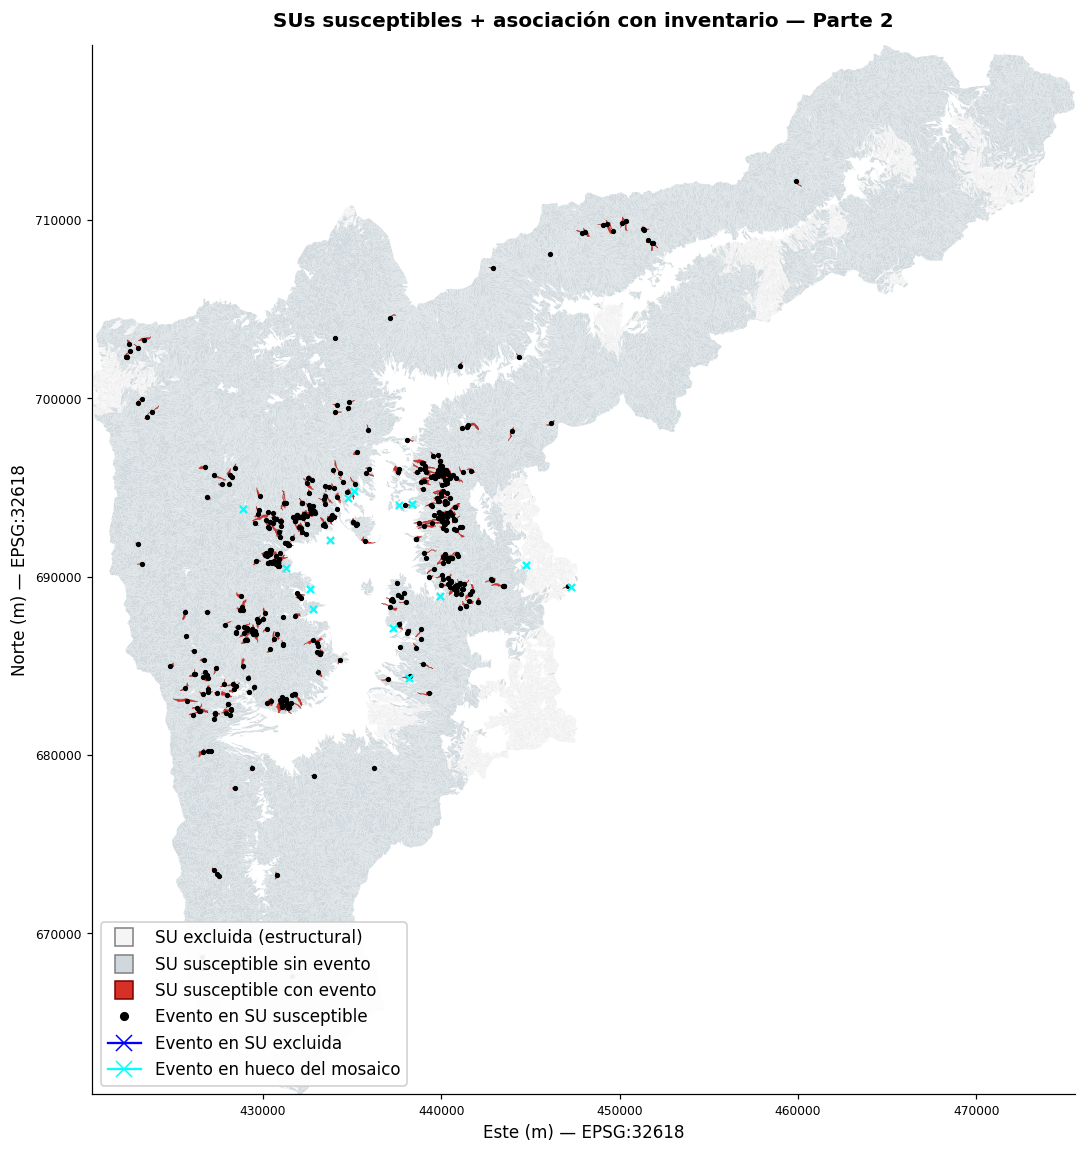

In [10]:
# Capa de SU susceptibles con/sin evento (sin duplicar)
su_unicas = (joined[[id_col, 'mm_si', 'geometry']]
             .groupby(id_col, as_index=False)
             .agg({'mm_si': 'max', 'geometry': 'first'}))
su_unicas = gpd.GeoDataFrame(su_unicas, geometry='geometry', crs=su.crs)

# Extent fijado al de las SU originales completas (mejor referencia visual)
minx, miny, maxx, maxy = su_full.total_bounds

fig, ax = plt.subplots(figsize=(10, 11))

# Capa base: SUs excluidas (para contexto)
su_excluidas_geom = su_full[su_full['incluir_parte2'] == False]
if len(su_excluidas_geom):
    su_excluidas_geom.plot(ax=ax, color='#f5f5f5',
                            edgecolor='#cccccc', linewidth=0.05,
                            alpha=0.6)

# SUs susceptibles sin evento
su_unicas[su_unicas.mm_si == 0].plot(
    ax=ax, color='#cfd8dc', edgecolor='white', linewidth=0.05)

# SUs susceptibles con evento
su_unicas[su_unicas.mm_si == 1].plot(
    ax=ax, color='#d73027', edgecolor='#7f0000', linewidth=0.15)

# Eventos dentro del dominio susceptible
events_in_susc.plot(ax=ax, color='black', markersize=6, marker='o')

# Eventos en SUs excluidas (caen en una SU excluida del filtrado)
if len(events_in_excluidas):
    events_in_excluidas.plot(ax=ax, color='blue', markersize=22,
                              marker='x', linewidth=1.5)

# Eventos en huecos del mosaico
if len(fuera_mosaico):
    fuera_mosaico.plot(ax=ax, color='cyan', markersize=22,
                        marker='x', linewidth=1.5)

handles = [
    Line2D([], [], marker='s', color='w', markerfacecolor='#f5f5f5',
           markeredgecolor='gray', markersize=12, label='SU excluida (estructural)'),
    Line2D([], [], marker='s', color='w', markerfacecolor='#cfd8dc',
           markeredgecolor='gray', markersize=12, label='SU susceptible sin evento'),
    Line2D([], [], marker='s', color='w', markerfacecolor='#d73027',
           markeredgecolor='#7f0000', markersize=12, label='SU susceptible con evento'),
    Line2D([], [], marker='o', color='w', markerfacecolor='black',
           markersize=7, label='Evento en SU susceptible'),
    Line2D([], [], marker='x', color='blue', markersize=10,
           label='Evento en SU excluida'),
    Line2D([], [], marker='x', color='cyan', markersize=10,
           label='Evento en hueco del mosaico'),
]
ax.legend(handles=handles, loc='lower left', frameon=True, framealpha=0.95)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect('equal')
ax.set_title('SUs susceptibles + asociación con inventario — Parte 2', pad=12)
ax.set_xlabel(f'Este (m) — {su.crs}')
ax.set_ylabel(f'Norte (m) — {su.crs}')
ax.ticklabel_format(style='plain', useOffset=False)
ax.tick_params(labelsize=8)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
#plt.savefig('mapa_susceptibles_con_inventario.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Resumen del balance de clases

Importante para la Parte 2: cuán desbalanceada queda la muestra para entrenar el modelo de umbrales.

In [11]:
n_pos = (joined.mm_si == 1).sum()
n_neg = (joined.mm_si == 0).sum()

print(f'Filas mm_si = 1 (con evento) : {n_pos:>8,}')
print(f'Filas mm_si = 0 (sin evento) : {n_neg:>8,}')
print(f'Total                        : {n_pos + n_neg:>8,}')
print(f'Razón negativos / positivos  : {n_neg / max(n_pos, 1):>8.1f} : 1')

# Comparativa del balance antes vs después del filtrado
if 'mm' in su_full.columns or 'n_mm' in su_full.columns:
    col_mm = 'mm' if 'mm' in su_full.columns else 'n_mm'
    n_pos_full_su = (su_full[col_mm] > 0).sum()
    n_neg_full_su = (su_full[col_mm] == 0).sum()
    razon_full = n_neg_full_su / max(n_pos_full_su, 1)
    razon_filt = n_neg / max(n_pos, 1)
    print(f'\nComparativa del balance (negativos:positivos):')
    print(f'  Antes del filtrado : {razon_full:>6.1f} : 1')
    print(f'  Después del filtrado: {razon_filt:>6.1f} : 1')
    print(f'  Mejora del balance : {razon_full / max(razon_filt, 1e-9):>6.2f}×')

# Distribución por tipo de movimiento
if 'tipo_movimiento' in joined.columns:
    print('\nTipo de movimiento (filas con evento):')
    print(joined.loc[joined.mm_si == 1, 'tipo_movimiento']
          .value_counts(dropna=False).to_string())

# Distribución de eventos por tipo de SU (clave para tu enfoque por tipo)
col_tipo = 'tipo_su' if 'tipo_su' in joined.columns else (
    'su_type' if 'su_type' in joined.columns else None)
if col_tipo:
    print(f'\nDistribución de eventos por {col_tipo} (solo filas con mm_si=1):')
    print(joined.loc[joined.mm_si == 1, col_tipo]
          .value_counts(dropna=False).sort_index().to_string())

Filas mm_si = 1 (con evento) :      479
Filas mm_si = 0 (sin evento) :   54,853
Total                        :   55,332
Razón negativos / positivos  :    114.5 : 1

Comparativa del balance (negativos:positivos):
  Antes del filtrado :   14.0 : 1
  Después del filtrado:  114.5 : 1
  Mejora del balance :   0.12×

Tipo de movimiento (filas con evento):
tipo_movimiento
Deslizamiento     335
Flujo             104
Otro               19
Caida de rocas      8
NaN                 6
Complejo            5
Traslacional        2

Distribución de eventos por tipo_su (solo filas con mm_si=1):
tipo_su
1     91
2    265
3     24
4     99


## 11. Guardado de la capa final

Se exporta como GeoPackage. Esta es la capa de entrada para el modelo de umbrales de lluvia (Parte 2).

In [12]:
out_dir = os.path.dirname(PATH_OUT)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

# Conversión a string para portabilidad (NaT no se exporta bien a GPKG)
joined_out = joined.copy()
joined_out['fecha_hora_evento'] = joined_out['fecha_hora_evento'].astype('string')

joined_out.to_file(PATH_OUT, layer=LAYER_OUTPUT, driver='GPKG')

print(f'✓ Archivo guardado: {PATH_OUT}')
print(f'  Capa            : {LAYER_OUTPUT}')
print(f'  Filas           : {len(joined_out):,}')
print(f'  Columnas        : {len(joined_out.columns)}')
print(f'\nColumnas finales:')
for c in joined_out.columns:
    print(f'  - {c}')

✓ Archivo guardado: /home/oisanchezp/Thesis/data/processed/su_susceptibles_con_inventario.gpkg
  Capa            : slope_units_eventos_parte2
  Filas           : 55,332
  Columnas        : 53

Columnas finales:
  - Id
  - gridcode
  - Shape_Leng
  - Shape_Area
  - slope_mean
  - curva_mean
  - acos_mean
  - asin_mean
  - aspect_mea
  - area
  - su_type
  - su_id
  - Codigo
  - Unidad_geo
  - Granulomet
  - Espesor_m
  - Gamma_kNm3
  - C_kPa
  - Phi
  - cobertura_cat
  - cobertura
  - n_mm
  - si_no
  - suelos
  - zona_lluvia
  - geologia
  - tipo_su
  - zona
  - log_area
  - mm
  - p_structural_given_zero
  - susceptible
  - mu_post
  - mu_post_km2
  - mu_q025
  - mu_q975
  - mu_sd
  - bym_mean
  - bym_sd
  - p_estructural
  - p_susceptible
  - clase_susc
  - incluir_parte2
  - geometry
  - fecha_hora_evento
  - latitud
  - longitud
  - tipo_movimiento
  - municipio
  - corregimiento
  - vereda_barrio
  - Codigo_estacion
  - mm_si


---

**Listo para la Parte 2.** El archivo `su_susceptibles_con_inventario.gpkg` contiene:

- Solo SUs marcadas como susceptibles por el filtrado de la Parte 1 (`incluir_parte2 == True`).
- Todas las columnas posteriores del modelo ZINB+BYM2 (`mu_post`, `p_estructural`, `p_susceptible`, `bym_mean`, etc.).
- Las columnas geomorfológicas originales (geología, cobertura, tipo_su, zona, etc.).
- Las columnas del evento: `fecha_hora_evento`, `latitud`, `longitud`, `tipo_movimiento`, `municipio`, `corregimiento`, `vereda_barrio`, `Codigo_estacion`.
- La columna `mm_si` con 1/0.
- SUs con varios eventos están duplicadas (una fila por evento).

**Próximos pasos:**
1. Construir el panel SU-día uniendo cada SU con sus lluvias diarias y la fase ENSO.
2. Filtrar el panel a días con lluvia significativa.
3. Ajustar el modelo de umbrales (NB multinivel + BYM2) **estratificado por tipo de SU**.
4. Calibrar los umbrales operativos por tipo y reportarlos a SIATA.